# MBG YouTube Sentiment Analysis & Text Mining

Analisis sentimen dan tren diskusi pada komentar YouTube terkait **Makan Bergizi Gratis (MBG)** menggunakan **Natural Language Processing (NLP)** dan **Deep Learning**.

> **Data source:** komentar YouTube yang dikumpulkan secara programatis.
>
> **Important:** dataset yang digunakan notebook ini adalah milik project ini sendiri. Hasil analisis harus dihitung ulang dari dataset ini dan tidak menggunakan hasil dari notebook/project lain.

## 1. Project Objective

### Analytical questions

Project ini mengubah komentar YouTube terkait **Makan Bergizi Gratis (MBG)** menjadi informasi yang dapat dianalisis untuk menjawab:

1. Bagaimana karakteristik dan pola percakapan pada dataset komentar YouTube?
2. Bagaimana distribusi sentiment **positive, negative, dan neutral**?
3. Kapan volume diskusi dan masing-masing sentiment mencapai puncaknya?
4. Kata apa yang paling sering muncul setelah preprocessing?
5. Seberapa baik model dapat membedakan komentar **positive vs negative**?
6. Bagaimana performa model NLP klasik dibanding model deep learning?

### End-to-end workflow

**Data validation → text preprocessing → exploratory text mining → sentiment analysis → sentiment trend → binary classification → TF-IDF baseline → BiLSTM → BiGRU → evaluation → interpretation**

> **Methodology note:** dataset YouTube adalah sampel berbasis platform dan tidak otomatis mewakili opini seluruh masyarakat Indonesia.

## 2. Data Preparation

Notebook membaca:

`data/mbg_comments_labeled.csv`

Dataset yang digunakan dalam portfolio run berisi **12.000 komentar YouTube berlabel**.

### Kolom utama

| Column | Description |
|---|---|
| `row_id` | identifier baris |
| `comment` | komentar YouTube asli |
| `comment_clean` | teks hasil cleaning awal |
| `published_at` | waktu publikasi komentar |
| `sentiment` | positive / negative / neutral |

### Labeling

Label sentiment menggunakan **AI-assisted semantic labeling**. Label tersebut merupakan weak/AI-assisted labels dan **bukan human gold-standard annotation**.

Karena itu, hasil klasifikasi harus dipahami sebagai performa model terhadap labeling scheme yang digunakan pada dataset ini.

In [1]:
# Environment setup
# Check core packages and prepare optional NLP/model dependencies.
import sys
import subprocess
import importlib.util

CORE_PACKAGES = [
    ("numpy", "numpy"),
    ("pandas", "pandas"),
    ("matplotlib", "matplotlib"),
    ("scikit-learn", "sklearn"),
]

missing_core = [
    package_name
    for package_name, module_name in CORE_PACKAGES
    if importlib.util.find_spec(module_name) is None
]

if missing_core:
    print("Installing missing core packages:", ", ".join(missing_core))
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        *missing_core
    ])
else:
    print("Core packages are ready.")

# NLTK, Sastrawi, TensorFlow and Optuna are handled as optional dependencies
# inside the relevant notebook sections so Run All can continue gracefully.
NLTK_AVAILABLE = importlib.util.find_spec("nltk") is not None
SASTRAWI_AVAILABLE = importlib.util.find_spec("Sastrawi") is not None
TENSORFLOW_AVAILABLE = importlib.util.find_spec("tensorflow") is not None
OPTUNA_AVAILABLE = importlib.util.find_spec("optuna") is not None

print("Python:", sys.version.split()[0])
print("NLTK available:", NLTK_AVAILABLE)
print("Sastrawi available:", SASTRAWI_AVAILABLE)
print("TensorFlow available:", TENSORFLOW_AVAILABLE)
print("Optuna available:", OPTUNA_AVAILABLE)

Core packages are ready.
Python: 3.11.16
NLTK available: True
Sastrawi available: True
TensorFlow available: True
Optuna available: True


In [2]:
import os
from pathlib import Path
import re
import html
import json
import random
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

PROJECT_ROOT = Path.cwd()

# Resolve the repository root from the current directory, its parents,
# or an immediate child project folder so the notebook is robust to
# common VS Code/Jupyter working-directory differences.
candidates = [PROJECT_ROOT, *PROJECT_ROOT.parents]
if PROJECT_ROOT.exists():
    candidates.extend(
        child for child in PROJECT_ROOT.iterdir()
        if child.is_dir()
    )

for candidate in candidates:
    candidate_data = candidate / "data" / "mbg_comments_labeled.csv"
    if candidate_data.exists():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError(
        "Dataset data/mbg_comments_labeled.csv tidak ditemukan. "
        "Pastikan notebook berada di dalam project yang memiliki folder data/."
    )

DATA_PATH = PROJECT_ROOT / "data" / "mbg_comments_labeled.csv"

YT_comments = pd.read_csv(DATA_PATH)

print(f"Dataset loaded: {YT_comments.shape[0]:,} rows x {YT_comments.shape[1]} columns")
print("Columns:")
print(YT_comments.columns.tolist())

Dataset loaded: 12,000 rows x 5 columns
Columns:
['row_id', 'comment', 'comment_clean', 'published_at', 'sentiment']


## 3. Data Validation

Sebelum preprocessing dan modeling, notebook memeriksa:
- jumlah baris dan kolom
- missing value
- duplicate berdasarkan `row_id`
- duplicate exact text sebagai informasi tambahan, bukan otomatis dihapus
- validitas tanggal
- distribusi label sentimen

Duplicate teks tidak otomatis dihapus karena komentar yang sama dapat muncul pada lebih dari satu baris. `row_id` digunakan sebagai identifier baris pada dataset labeling.

In [3]:
required_columns = [
    "row_id",
    "comment",
    "comment_clean",
    "published_at",
    "sentiment"
]

missing_required = [
    c for c in required_columns
    if c not in YT_comments.columns
]

if missing_required:
    raise ValueError(
        f"Kolom wajib tidak ditemukan: {missing_required}"
    )

print("Total dataset rows:", f"{len(YT_comments):,}")
print("Columns:", YT_comments.columns.tolist())

print("\nMissing values:")
display(
    YT_comments.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("missing")
)

print(
    "\nDuplicate row_id:",
    YT_comments["row_id"].duplicated().sum()
)

print(
    "Duplicate exact comment:",
    YT_comments["comment"].duplicated().sum()
)

YT_comments["published_at"] = pd.to_datetime(
    YT_comments["published_at"],
    errors="coerce",
    utc=True
)

print(
    "\nInvalid published_at:",
    YT_comments["published_at"].isna().sum()
)

print("\nSentiment values:")
print(
    YT_comments["sentiment"]
    .value_counts(dropna=False)
)

Total dataset rows: 12,000
Columns: ['row_id', 'comment', 'comment_clean', 'published_at', 'sentiment']

Missing values:


,missing
comment_clean,1
row_id,0
comment,0
published_at,0
sentiment,0



Duplicate row_id: 0
Duplicate exact comment: 453

Invalid published_at: 0

Sentiment values:
sentiment
neutral     8900
negative    2880
positive     220
Name: count, dtype: int64


## 4. Normalize Sentiment Labels

Label yang digunakan:
- `positive`
- `negative`
- `neutral`

Untuk modeling deep learning:
- `positive = 0`
- `negative = 1`

`neutral` tetap dipertahankan untuk analisis keseluruhan dan dikeluarkan hanya dari binary classifier.

Dataset ini berisi **12.000 komentar berlabel**. Label dibuat menggunakan **AI-assisted semantic labeling**, sehingga hasil model perlu diinterpretasikan sebagai model yang belajar dari weak/AI-assisted labels, bukan human gold standard.

In [4]:
YT_comments["sentiment"] = (
    YT_comments["sentiment"]
    .astype("string")
    .str.strip()
    .str.lower()
    .replace({
        "pos": "positive",
        "neg": "negative",
        "netral": "neutral"
    })
)

VALID_LABELS = {"positive", "negative", "neutral"}

invalid_labels = sorted(
    set(YT_comments["sentiment"].dropna().unique()) - VALID_LABELS
)
if invalid_labels:
    print("Warning - unexpected labels:", invalid_labels)

labeled_mask = YT_comments["sentiment"].isin(VALID_LABELS)
YT_labeled = YT_comments.loc[labeled_mask].copy()

LABELS_READY = len(YT_labeled) > 0

print(f"Rows with valid labels: {len(YT_labeled):,} / {len(YT_comments):,}")
print("\nLabel distribution:")
if LABELS_READY:
    print(YT_labeled["sentiment"].value_counts())
else:
    print("Belum ada label valid. Silakan isi kolom 'sentiment' terlebih dahulu.")

BINARY_LABELS_READY = (
    LABELS_READY
    and YT_labeled["sentiment"].isin(["positive", "negative"]).sum() > 0
    and YT_labeled.loc[
        YT_labeled["sentiment"].isin(["positive", "negative"]), "sentiment"
    ].nunique() == 2
)

print("\nBinary positive/negative ready:", BINARY_LABELS_READY)

Rows with valid labels: 12,000 / 12,000

Label distribution:
sentiment
neutral     8900
negative    2880
positive     220
Name: count, dtype: Int64

Binary positive/negative ready: True


## 5. Text Preprocessing

Dataset sudah memiliki `comment_clean`, sehingga notebook menggunakannya sebagai basis preprocessing.

Tahapan NLP:
1. HTML/entity normalization
2. URL / mention cleanup
3. hashtag symbol removal tetapi kata hashtag dipertahankan
4. case folding
5. punctuation normalization
6. slang normalization
7. stopword removal dengan **negation words dipertahankan**
8. **optional** stemming Bahasa Indonesia menggunakan Sastrawi
9. hasil akhir disimpan di `text_preprocessed`

> **Performance note:** Sastrawi dapat menjadi bottleneck pada komentar panjang. Karena itu `USE_STEMMING = False` secara default agar notebook dapat dijalankan lebih cepat. Stemming tetap tersedia dan dapat diaktifkan dengan mengubah nilai tersebut menjadi `True`.

In [5]:
# Indonesian stopword handling
# NLTK is optional. A fallback list is provided so the notebook can run
# even when the NLTK stopwords corpus is unavailable.

NEGATION_WORDS = {
    "tidak", "tak", "bukan", "jangan", "belum",
    "gak", "nggak", "ga", "ngga", "tdk", "kurang"
}

FALLBACK_STOPWORDS = {
    "yang", "dan", "di", "ke", "dari", "untuk", "pada", "dengan",
    "ini", "itu", "ada", "akan", "atau", "juga", "saja", "sudah",
    "sangat", "lebih", "dalam", "karena", "kalau", "kalo", "jadi",
    "buat", "bagi", "oleh", "sebagai", "dapat", "bisa", "mereka",
    "kita", "kami", "saya", "aku", "anda", "dia", "nya", "lah",
    "pun", "kok", "tuh", "mah", "kan", "aja"
}

if NLTK_AVAILABLE:
    try:
        from nltk.corpus import stopwords
        INDONESIAN_STOPWORDS = set(
            stopwords.words("indonesian")
        )
    except (LookupError, ImportError):
        INDONESIAN_STOPWORDS = FALLBACK_STOPWORDS.copy()
else:
    INDONESIAN_STOPWORDS = FALLBACK_STOPWORDS.copy()

INDONESIAN_STOPWORDS = (
    INDONESIAN_STOPWORDS - NEGATION_WORDS
)

slang_words = {
    "gk": "gak",
    "ga": "gak",
    "nggak": "gak",
    "ngga": "gak",
    "tdk": "tidak",
    "bkn": "bukan",
    "jgn": "jangan",
    "krn": "karena",
    "knp": "kenapa",
    "knpa": "kenapa",
    "ap": "apa",
    "tp": "tapi",
    "tpi": "tapi",
    "bgt": "banget",
    "bgd": "banget",
    "gt": "gitu",
    "jg": "juga",
    "skg": "sekarang",
    "udh": "sudah",
    "sdh": "sudah",
    "dah": "sudah",
    "yg": "yang",
    "dgn": "dengan",
    "lg": "lagi",
    "tau": "tahu",
    "smua": "semua",
    "org": "orang",
    "dpt": "dapat",
    "msh": "masih",
    "utk": "untuk",
    "lbh": "lebih",
    "dri": "dari",
    "dr": "dari",
    "kyk": "kayak",
    "mkn": "makan",
    "mslh": "masalah",
    "bnyk": "banyak",
    "mlh": "malah",
    "nnti": "nanti",
    "tuh": "itu",
    "cuma": "hanya",
    "abis": "habis",
    "bener": "benar",
    "emg": "memang",
    "emang": "memang"
}

USE_STEMMING = False

if USE_STEMMING and SASTRAWI_AVAILABLE:
    from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
    from functools import lru_cache
    stemmer = StemmerFactory().create_stemmer()

    @lru_cache(maxsize=10000)
    def stem_cached(text):
        return stemmer.stem(text) if text else ""
else:
    stem_cached = lambda text: text


def clean_for_nlp(text):
    text = "" if pd.isna(text) else str(text)
    text = html.unescape(text)

    text = re.sub(
        r"http\S+|www\.\S+",
        " ",
        text
    )

    text = re.sub(
        r"@[A-Za-z0-9_]+",
        " ",
        text
    )

    text = re.sub(
        r"#",
        "",
        text
    )

    text = text.replace("\n", " ")
    text = text.lower()

    text = re.sub(
        r"[^a-z0-9\s]",
        " ",
        text
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    tokens = text.split()

    tokens = [
        slang_words.get(tok, tok)
        for tok in tokens
    ]

    tokens = [
        tok
        for tok in tokens
        if tok not in INDONESIAN_STOPWORDS
        and len(tok) > 1
    ]

    if not tokens:
        return ""

    normalized_text = " ".join(tokens)

    if USE_STEMMING:
        if not SASTRAWI_AVAILABLE:
            return normalized_text
        normalized_text = stem_cached(normalized_text)

    return re.sub(
        r"\s+",
        " ",
        normalized_text
    ).strip()


source_text_col = (
    "comment_clean"
    if "comment_clean" in YT_comments.columns
    else "comment"
)

YT_comments["text_source"] = (
    YT_comments[source_text_col]
    .fillna(YT_comments["comment"])
)

YT_comments["text_preprocessed"] = (
    YT_comments["text_source"]
    .apply(clean_for_nlp)
)

print("Stemming enabled:", USE_STEMMING)
display(
    YT_comments[
        ["comment", "text_source", "text_preprocessed"]
    ].head(10)
)

Stemming enabled: False


,comment,text_source,text_preprocessed
0,Dimane itu ya Allah semoga narik kalau mbg tid...,dimane itu ya allah semoga narik kalau mbg tid...,dimane ya allah semoga narik mbg tidak keracun...
1,Presiden Prabowo Ganti\n\nPresiden Pemilu 2029...,presiden prabowo ganti presiden pemilu 2029 iya 👍,presiden prabowo ganti presiden pemilu 2029 iya
2,Presiden Prabowo bilang sekolah Seperti pikir ...,presiden prabowo bilang sekolah seperti pikir ...,presiden prabowo bilang sekolah seperti pikir ...
3,Hancurkan generasi muda dengan uang rakyat 😂😂😂...,hancurkan generasi muda dengan uang rakyat 😂😂😂...,hancurkan generasi muda uang rakyat keruk sda ...
4,Di sekolah ku ada mbg tapi gakpapa kok aku,di sekolah ku ada mbg tapi gakpapa kok aku,sekolah ku mbg tapi gakpapa
5,MBG😢😢😢,mbg😢😢😢,mbg
6,KENAPA KEPALA KELUARGA KORBAN KERACUNAN GAK AD...,kenapa kepala keluarga korban keracunan gak ad...,kenapa kepala keluarga korban keracunan gak de...
7,Aku jadi takutdeh😢,aku jadi takutdeh😢,takutdeh
8,Woi Prabowo aji** udah deh kokumsi makanan mbg,woi prabowo aji** udah deh kokumsi makanan mbg,woi prabowo aji udah deh kokumsi makanan mbg
9,Politik sangatlah kejam... ternyata rakyat Ind...,politik sangatlah kejam.. ternyata rakyat indo...,politik sangatlah kejam ternyata rakyat indone...


In [6]:
empty_after_preprocessing = (
    YT_comments["text_preprocessed"].str.len() == 0
).sum()

print(
    f"Empty text after preprocessing: "
    f"{empty_after_preprocessing:,}"
)

print("\nSample preprocessing:")
display(
    YT_comments[
        ["comment", "text_preprocessed"]
    ].sample(
        min(10, len(YT_comments)),
        random_state=SEED
    )
)

Empty text after preprocessing: 561

Sample preprocessing:


,comment,text_preprocessed
1935,Banggg kalo ngak gitu ngak bisa korupsi lahhhh...,bangg ngak gitu ngak korupsi lahh piye too kar...
6494,Saya setuju kalau mbg dihentikan diganti sj d...,setuju mbg dihentikan diganti sj dengsn harga ...
1720,Rampok berkedok mbg. \nSangat kejam,rampok berkedok mbg kejam
9120,Makin lama makin sadis pemerintah ke rakyat..\...,makin lama makin sadis pemerintah rakyat thun ...
360,Ini sekarang bukan makanan bergizi gratis tp m...,sekarang bukan makanan bergizi gratis tapi mak...
9663,Entah ini ulah yg mau menjelekkan program mbg ...,entah ulah mau menjelekkan program mbg memang ...
5277,Hebat hebat presiden kita mantap betul ya woi ...,hebat hebat presiden mantap betul ya woi masya...
8546,Aku Uda dpt😊,uda
2221,itu tebu bukan bambyu😭😭,tebu bukan bambyu
4617,"Mantap ibu ini sangat cerdas,",mantap ibu cerdas


## 6. Exploratory Text Analysis

Bagian ini digunakan untuk melihat:
- panjang komentar
- volume komentar per tanggal
- kata yang paling sering muncul
- distribusi sentimen jika label sudah tersedia

Tidak ada insight tekstual yang ditulis sebelum grafik/tabel dihitung dari dataset.

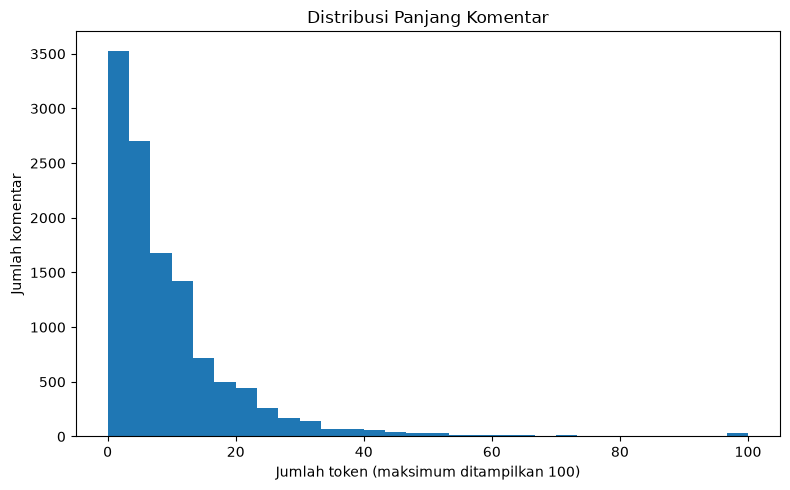

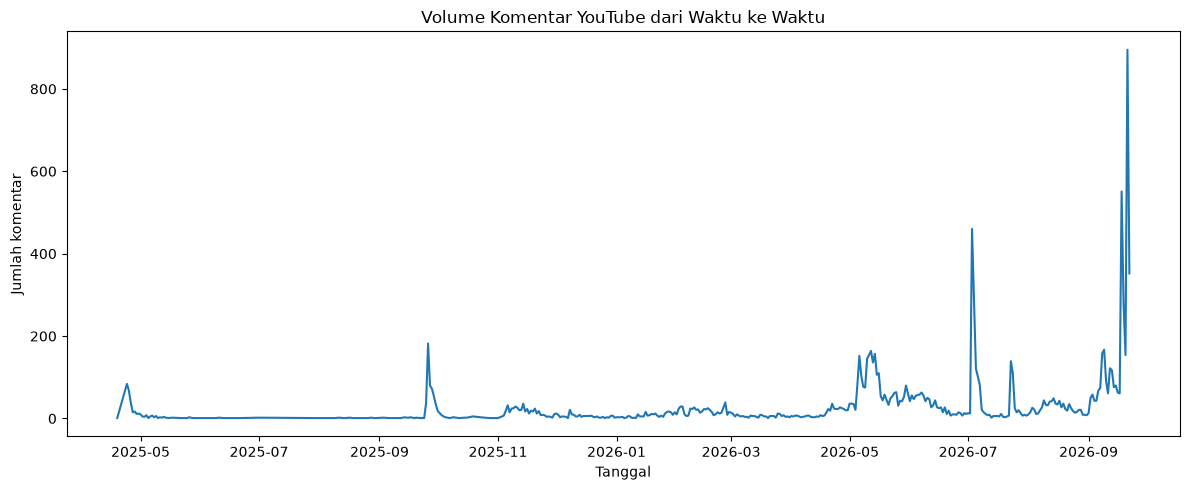

In [7]:
YT_comments["comment_length"] = (
    YT_comments["text_preprocessed"]
    .str.split()
    .str.len()
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(
    YT_comments["comment_length"].clip(upper=100),
    bins=30
)
ax.set_title("Distribusi Panjang Komentar")
ax.set_xlabel("Jumlah token (maksimum ditampilkan 100)")
ax.set_ylabel("Jumlah komentar")
plt.tight_layout()
plt.show()

daily_volume = (
    YT_comments.dropna(subset=["published_at"])
    .assign(
        date=lambda d: d["published_at"].dt.date
    )
    .groupby("date")
    .size()
)

fig, ax = plt.subplots(figsize=(12, 5))
daily_volume.plot(ax=ax)
ax.set_title("Volume Komentar YouTube dari Waktu ke Waktu")
ax.set_xlabel("Tanggal")
ax.set_ylabel("Jumlah komentar")
plt.tight_layout()
plt.show()

In [8]:
all_words = " ".join(YT_comments["text_preprocessed"].dropna())
word_counts = Counter(all_words.split())

top_words_overall = pd.DataFrame(
    word_counts.most_common(20),
    columns=["word", "count"]
)

display(top_words_overall)

,word,count
0,mbg,5158
1,gak,1678
2,tidak,1218
3,makan,1111
4,anak,1064
5,rakyat,995
6,sekolah,937
7,indonesia,917
8,orang,874
9,tapi,848


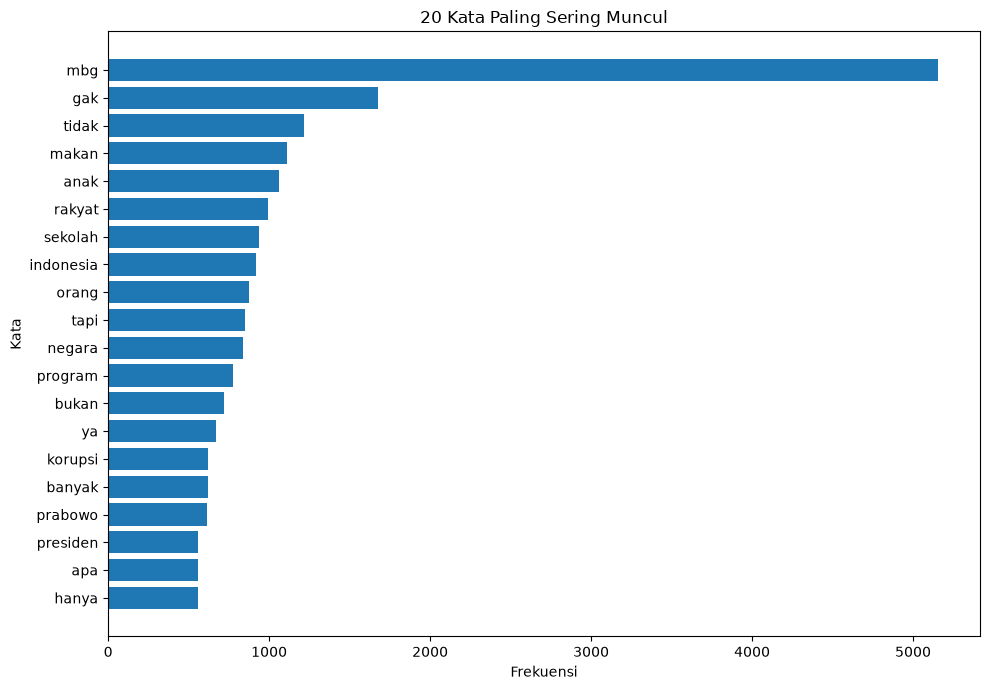

In [9]:
fig, ax = plt.subplots(figsize=(10, 7))
plot_df = top_words_overall.sort_values("count")
ax.barh(plot_df["word"], plot_df["count"])
ax.set_title("20 Kata Paling Sering Muncul")
ax.set_xlabel("Frekuensi")
ax.set_ylabel("Kata")
plt.tight_layout()
plt.show()

## 7. Sentiment Distribution

Bagian ini hanya dijalankan ketika `sentiment` sudah berisi label valid.

**Important:** notebook tidak lagi menggunakan Indonesian Sentiment Lexicon/InSet sebagai ground-truth label. Label supervised harus berasal dari proses labeling dataset.

,count,percentage
sentiment,,
positive,220,1.83
negative,2880,24.0
neutral,8900,74.17


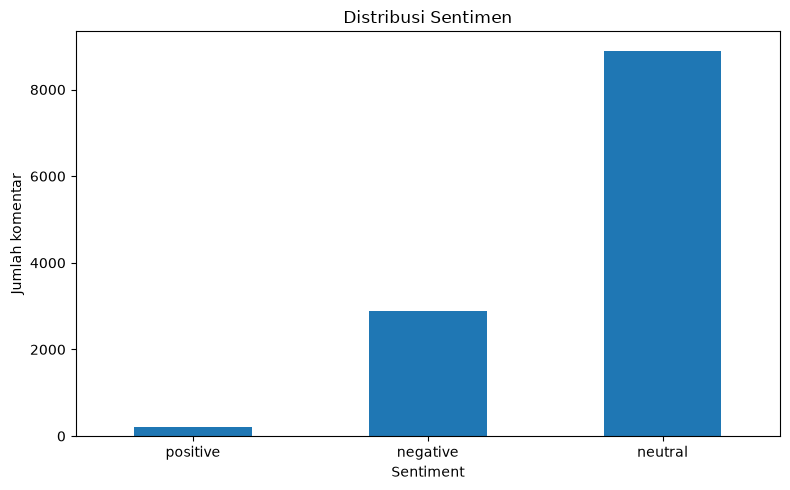

In [10]:
if not LABELS_READY:
    print("Sentiment distribution belum tersedia karena label belum ada.")
else:
    sentiment_counts = (
        YT_labeled["sentiment"]
        .value_counts()
        .reindex(["positive", "negative", "neutral"], fill_value=0)
    )
    sentiment_pct = (
        sentiment_counts / sentiment_counts.sum() * 100
    ).round(2)

    sentiment_summary = pd.DataFrame({
        "count": sentiment_counts,
        "percentage": sentiment_pct
    })
    display(sentiment_summary)

    fig, ax = plt.subplots(figsize=(8, 5))
    sentiment_counts.plot(kind="bar", ax=ax)
    ax.set_title("Distribusi Sentimen")
    ax.set_xlabel("Sentiment")
    ax.set_ylabel("Jumlah komentar")
    ax.tick_params(axis="x", rotation=0)
    plt.tight_layout()
    plt.show()

## 8. Sentiment Trend

Untuk komentar yang sudah memiliki label, kita dapat melihat perubahan volume **positive / negative / neutral** berdasarkan `published_at`.

Trend menunjukkan **kapan** diskusi berubah; penyebab lonjakan harus dianalisis terpisah dengan sumber eksternal dan tidak boleh disimpulkan hanya karena dua kejadian terjadi pada tanggal yang berdekatan.

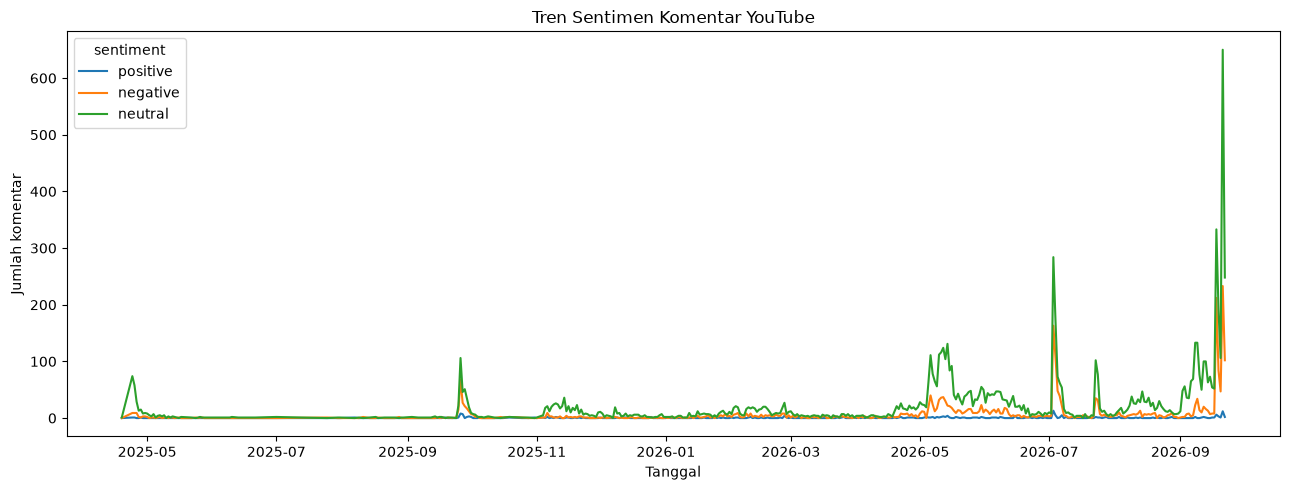

In [11]:
if not LABELS_READY:
    print("Belum ada label sentiment. Gunakan daily_volume untuk melihat volume diskusi.")
else:
    sentiment_trend = (
        YT_labeled.dropna(subset=["published_at"])
        .assign(date=lambda d: d["published_at"].dt.date)
        .groupby(["date", "sentiment"])
        .size()
        .unstack(fill_value=0)
    )

    for label in ["positive", "negative", "neutral"]:
        if label not in sentiment_trend.columns:
            sentiment_trend[label] = 0

    sentiment_trend = sentiment_trend[["positive", "negative", "neutral"]]

    fig, ax = plt.subplots(figsize=(13, 5))
    sentiment_trend.plot(ax=ax)
    ax.set_title("Tren Sentimen Komentar YouTube")
    ax.set_xlabel("Tanggal")
    ax.set_ylabel("Jumlah komentar")
    plt.tight_layout()
    plt.show()

In [12]:
if not LABELS_READY:
    print("Insight sentiment belum tersedia karena label belum ada.")
else:
    print("=== Data-driven EDA Insights ===")
    total_labeled = len(YT_labeled)
    dominant_label = sentiment_counts.idxmax()
    dominant_pct = sentiment_pct.loc[dominant_label]
    peak_date = daily_volume.idxmax() if len(daily_volume) else None
    peak_volume = int(daily_volume.max()) if len(daily_volume) else 0

    print(f"Total labeled comments: {total_labeled:,}")
    print(f"Dominant sentiment: {dominant_label} ({dominant_pct:.2f}%)")
    if peak_date is not None:
        print(f"Peak discussion date by volume: {peak_date} ({peak_volume:,} comments)")
    if len(sentiment_trend):
        for label in ["positive", "negative", "neutral"]:
            peak = sentiment_trend[label].idxmax()
            peak_n = int(sentiment_trend[label].max())
            print(f"Peak {label}: {peak} ({peak_n:,} comments)")

    print("\nTop 5 words:")
    display(top_words_overall.head(5))

    print("\nInterpretation note: angka di atas adalah deskripsi dataset YouTube ini; "
          "bukan estimasi opini seluruh masyarakat dan bukan bukti sebab-akibat.")

=== Data-driven EDA Insights ===
Total labeled comments: 12,000
Dominant sentiment: neutral (74.17%)
Peak discussion date by volume: 2026-09-21 (895 comments)
Peak positive: 2026-07-03 (13 comments)
Peak negative: 2026-09-21 (233 comments)
Peak neutral: 2026-09-21 (650 comments)

Top 5 words:


,word,count
0,mbg,5158
1,gak,1678
2,tidak,1218
3,makan,1111
4,anak,1064



Interpretation note: angka di atas adalah deskripsi dataset YouTube ini; bukan estimasi opini seluruh masyarakat dan bukan bukti sebab-akibat.


## 9. Prepare Binary Classification Dataset

Model deep learning mengikuti pendekatan project template: klasifikasi dua kelas.

Encoding:
- `positive = 0`
- `negative = 1`

Komentar `neutral` tidak digunakan dalam binary model, tetapi tetap ada pada `YT_comments`.

In [13]:
BINARY_LABEL_MAP = {
    "positive": 0,
    "negative": 1
}

YT_comments_binary = (
    YT_comments[
        YT_comments["sentiment"].isin(
            BINARY_LABEL_MAP.keys()
        )
        &
        (
            YT_comments["text_preprocessed"].str.len() > 0
        )
    ]
    .copy()
)

BINARY_LABELS_READY = (
    len(YT_comments_binary) > 0
    and YT_comments_binary["sentiment"].nunique() == 2
)

if BINARY_LABELS_READY:
    YT_comments_binary["label"] = (
        YT_comments_binary["sentiment"]
        .map(BINARY_LABEL_MAP)
    )

    texts = (
        YT_comments_binary["text_preprocessed"]
        .values
    )

    y = (
        YT_comments_binary["label"]
        .values
        .astype(int)
    )

    print(
        "Binary dataset:",
        f"{len(YT_comments_binary):,}"
    )

    print("\nBinary label distribution:")
    print(
        YT_comments_binary[
            "sentiment"
        ].value_counts()
    )
else:
    texts = np.array([])
    y = np.array([], dtype=int)

    print(
        "Binary modeling skipped because "
        "both positive and negative labels are not available."
    )

Binary dataset: 3,100

Binary label distribution:
sentiment
negative    2880
positive     220
Name: count, dtype: Int64


## 10. Train-Test Split

Dataset binary dibagi menjadi training set dan test set menggunakan **stratified split**.

- Training set digunakan untuk mempelajari pola bahasa dan label.
- Test set disimpan sampai evaluasi akhir.
- `stratify=y` menjaga proporsi positive/negative tetap relatif konsisten di train dan test.
- `random_state=42` membuat pembagian reproducible.

Tokenizer hanya dipelajari dari training set sehingga test set tidak ikut membentuk vocabulary.

In [14]:
from sklearn.model_selection import train_test_split

TEST_SIZE = 0.20

if not BINARY_LABELS_READY:
    X_train = X_test = np.array([])
    y_train = y_test = np.array([], dtype=int)
    print("Train-test split skipped because binary labels are not ready.")
else:
    X_train, X_test, y_train, y_test = train_test_split(
        texts,
        y,
        test_size=TEST_SIZE,
        random_state=SEED,
        stratify=y
    )

    print(f"Train size: {len(X_train):,}")
    print(f"Test size : {len(X_test):,}")
    print("\nTrain label distribution:")
    print(pd.Series(y_train).map({0: "positive", 1: "negative"}).value_counts())
    print("\nTest label distribution:")
    print(pd.Series(y_test).map({0: "positive", 1: "negative"}).value_counts())

Train size: 2,480
Test size : 620

Train label distribution:
negative    2304
positive     176
Name: count, dtype: int64

Test label distribution:
negative    576
positive     44
Name: count, dtype: int64


## 11. CPU-Friendly Baseline — TF-IDF + Logistic Regression

Sebelum menggunakan deep learning, project membuat baseline klasik yang lebih ringan:

**TF-IDF → Logistic Regression**

TF-IDF merepresentasikan kata dan bi-gram berdasarkan bobot kepentingannya di dalam korpus, kemudian Logistic Regression melakukan binary classification.

Baseline ini penting sebagai pembanding agar kompleksitas deep learning memiliki benchmark yang jelas.

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score

tfidf_vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

tfidf_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=SEED
)

tfidf_model.fit(X_train_tfidf, y_train)
tfidf_pred = tfidf_model.predict(X_test_tfidf)

tfidf_accuracy = accuracy_score(y_test, tfidf_pred)
tfidf_f1_macro = f1_score(y_test, tfidf_pred, average="macro")

print(f"TF-IDF Accuracy : {tfidf_accuracy:.4f}")
print(f"TF-IDF Macro F1 : {tfidf_f1_macro:.4f}")
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        tfidf_pred,
        target_names=["positive", "negative"],
        zero_division=0
    )
)

TF-IDF Accuracy : 0.9339
TF-IDF Macro F1 : 0.7466

Classification Report:
              precision    recall  f1-score   support

    positive       0.53      0.52      0.53        44
    negative       0.96      0.97      0.96       576

    accuracy                           0.93       620
   macro avg       0.75      0.74      0.75       620
weighted avg       0.93      0.93      0.93       620



## 12. Tokenization & Padding

Model input pipeline:

**Text → Tokenizer → Integer Sequence → Padding → Embedding**

Tokenizer hanya dipelajari dari training set untuk mengurangi data leakage.

In [16]:
MAX_VOCAB_SIZE = 20000
MAX_LENGTH = 200

if not BINARY_LABELS_READY:
    tokenizer = None
    X_train_padded = np.empty((0, MAX_LENGTH), dtype=np.int32)
    X_test_padded = np.empty((0, MAX_LENGTH), dtype=np.int32)
    vocab_size = 0
    print("Tokenization skipped because binary labels are not ready.")
elif not TENSORFLOW_AVAILABLE:
    tokenizer = None
    X_train_padded = np.empty((0, MAX_LENGTH), dtype=np.int32)
    X_test_padded = np.empty((0, MAX_LENGTH), dtype=np.int32)
    vocab_size = 0
    print(
        "TensorFlow tidak tersedia. Tokenization/modeling akan dilewati "
        "tanpa menghentikan Run All. Install TensorFlow untuk menjalankan model."
    )
else:
    from tensorflow.keras.preprocessing.text import Tokenizer
    from tensorflow.keras.preprocessing.sequence import pad_sequences

    tokenizer = Tokenizer(
        num_words=MAX_VOCAB_SIZE,
        oov_token="<OOV>"
    )

    tokenizer.fit_on_texts(X_train)

    train_sequences = tokenizer.texts_to_sequences(X_train)
    test_sequences = tokenizer.texts_to_sequences(X_test)

    X_train_padded = pad_sequences(
        train_sequences,
        maxlen=MAX_LENGTH,
        padding="post",
        truncating="post"
    )

    X_test_padded = pad_sequences(
        test_sequences,
        maxlen=MAX_LENGTH,
        padding="post",
        truncating="post"
    )

    vocab_size = min(
        MAX_VOCAB_SIZE,
        len(tokenizer.word_index) + 1
    )

    print("Vocabulary size:", vocab_size)
    print("Padded train shape:", X_train_padded.shape)
    print("Padded test shape :", X_test_padded.shape)

Vocabulary size: 7523
Padded train shape: (2480, 200)
Padded test shape : (620, 200)


## 13. Baseline Deep Learning Model — Bidirectional LSTM

BiLSTM digunakan sebagai baseline deep-learning.

Arsitektur:

**Embedding → Bidirectional LSTM → Dropout → Bidirectional LSTM → Dropout → Dense → Sigmoid**

Model dilatih dengan class weighting karena distribusi binary class sangat tidak seimbang.

Evaluasi dilakukan pada test set yang tidak digunakan untuk training.

In [17]:
baseline_f1_macro = np.nan
baseline_f1_negative = np.nan
baseline_accuracy = np.nan
baseline_pred = np.array([], dtype=int)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)
from sklearn.utils.class_weight import compute_class_weight

if not BINARY_LABELS_READY:
    baseline_model = None
    baseline_history = None
    print(
        "Baseline model skipped because binary labels are not ready."
    )
elif not TENSORFLOW_AVAILABLE:
    baseline_model = None
    baseline_history = None
    print(
        "TensorFlow is not installed. "
        "Baseline BiLSTM is skipped without raising an error."
    )
else:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import (
        Embedding,
        Bidirectional,
        LSTM,
        Dense,
        Dropout
    )
    from tensorflow.keras.callbacks import (
        EarlyStopping,
        ModelCheckpoint
    )
    from tensorflow.keras.optimizers import Adam

    tf.random.set_seed(SEED)

    classes = np.unique(y_train)

    class_weights_values = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_train
    )

    class_weight = dict(
        zip(classes, class_weights_values)
    )

    baseline_model = Sequential([
        Embedding(
            input_dim=vocab_size,
            output_dim=128,
            input_length=MAX_LENGTH
        ),
        Bidirectional(
            LSTM(
                64,
                return_sequences=True
            )
        ),
        Dropout(0.5),
        Bidirectional(
            LSTM(32)
        ),
        Dropout(0.3),
        Dense(
            32,
            activation="relu"
        ),
        Dense(
            1,
            activation="sigmoid"
        )
    ])

    baseline_model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    baseline_checkpoint = ModelCheckpoint(
        "best_baseline_bilstm.keras",
        save_best_only=True,
        monitor="val_accuracy",
        mode="max"
    )

    baseline_early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )

    baseline_history = baseline_model.fit(
        X_train_padded,
        y_train,
        epochs=20,
        batch_size=64,
        validation_split=0.20,
        class_weight=class_weight,
        callbacks=[
            baseline_early_stopping,
            baseline_checkpoint
        ],
        verbose=1
    )

    baseline_prob = baseline_model.predict(
        X_test_padded,
        verbose=0
    ).ravel()

    baseline_pred = (
        baseline_prob >= 0.5
    ).astype(int)

    print(
        classification_report(
            y_test,
            baseline_pred,
            target_names=["positive", "negative"],
            zero_division=0
        )
    )

In [18]:
if BINARY_LABELS_READY and baseline_model is not None:
    baseline_accuracy = accuracy_score(y_test, baseline_pred)
    baseline_f1_macro = f1_score(
        y_test,
        baseline_pred,
        average="macro"
    )
    baseline_f1_negative = f1_score(
        y_test,
        baseline_pred,
        pos_label=1
    )

    print(f"Baseline Accuracy : {baseline_accuracy:.4f}")
    print(f"Baseline Macro F1 : {baseline_f1_macro:.4f}")
    print(f"Negative-class F1 : {baseline_f1_negative:.4f}")
    print("\nBaseline Classification Report:")
    print(
        classification_report(
            y_test,
            baseline_pred,
            target_names=["positive", "negative"],
            zero_division=0
        )
    )
else:
    baseline_accuracy = np.nan
    baseline_f1_macro = np.nan
    baseline_f1_negative = np.nan
    print("Baseline metrics skipped because the BiLSTM model is unavailable.")

Baseline Accuracy : 0.8887
Baseline Macro F1 : 0.6410
Negative-class F1 : 0.9392

Baseline Classification Report:
              precision    recall  f1-score   support

    positive       0.30      0.41      0.34        44
    negative       0.95      0.93      0.94       576

    accuracy                           0.89       620
   macro avg       0.62      0.67      0.64       620
weighted avg       0.91      0.89      0.90       620



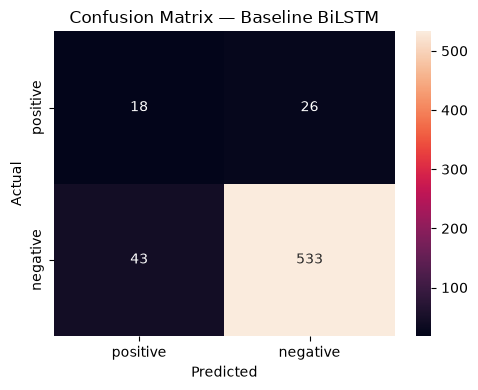

In [19]:
import seaborn as sns
if BINARY_LABELS_READY and baseline_model is not None:
    cm = confusion_matrix(y_test, baseline_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=["positive", "negative"],
        yticklabels=["positive", "negative"]
    )
    plt.title("Confusion Matrix — Baseline BiLSTM")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()
else:
    print("Baseline BiLSTM confusion matrix skipped because the model is unavailable.")

## 14. Hyperparameter Tuning with Optuna

Optuna disediakan untuk mencari konfigurasi **Bidirectional GRU**.

Hyperparameter yang dapat dituning:
- embedding dimension
- GRU units
- dropout
- learning rate
- L2 regularization

**Portfolio run saat ini:** `RUN_OPTUNA = False`, sehingga BiGRU menggunakan parameter default yang ditetapkan notebook. Tuning tetap tersedia untuk eksperimen lanjutan dan tidak menggunakan test set.

In [20]:
RUN_OPTUNA = os.getenv("RUN_OPTUNA", "0") == "1"
N_TRIALS = 10
TUNE_EPOCHS = 8

if not TENSORFLOW_AVAILABLE:
    print(
        "TensorFlow is not installed. "
        "Optuna/model tuning is skipped."
    )
elif RUN_OPTUNA and not OPTUNA_AVAILABLE:
    print(
        "Optuna is not installed. "
        "Set RUN_OPTUNA = False or install optuna to enable tuning."
    )
else:
    from tensorflow.keras.regularizers import l2
    from tensorflow.keras.layers import GRU

    if RUN_OPTUNA:
        import optuna

    def build_bigru_model(params):
        model = Sequential([
            Embedding(
                input_dim=vocab_size,
                output_dim=params["embedding_dim"],
                input_length=MAX_LENGTH
            ),
            Bidirectional(
                GRU(
                    params["gru_units1"],
                    return_sequences=True,
                    kernel_regularizer=l2(
                        params["l2_reg"]
                    )
                )
            ),
            Dropout(
                params["dropout_rate1"]
            ),
            Bidirectional(
                GRU(
                    params["gru_units2"],
                    kernel_regularizer=l2(
                        params["l2_reg"]
                    )
                )
            ),
            Dropout(
                params["dropout_rate2"]
            ),
            Dense(
                32,
                activation="relu",
                kernel_regularizer=l2(
                    params["l2_reg"]
                )
            ),
            Dense(
                1,
                activation="sigmoid"
            )
        ])

        model.compile(
            optimizer=Adam(
                learning_rate=params["learning_rate"]
            ),
            loss="binary_crossentropy",
            metrics=["accuracy"]
        )

        return model

    if BINARY_LABELS_READY and RUN_OPTUNA:
        def objective(trial):
            tf.keras.backend.clear_session()

            params = {
                "embedding_dim": trial.suggest_categorical(
                    "embedding_dim",
                    [64, 128, 256]
                ),
                "gru_units1": trial.suggest_categorical(
                    "gru_units1",
                    [32, 64, 128]
                ),
                "gru_units2": trial.suggest_categorical(
                    "gru_units2",
                    [16, 32, 64]
                ),
                "dropout_rate1": trial.suggest_float(
                    "dropout_rate1",
                    0.2,
                    0.6
                ),
                "dropout_rate2": trial.suggest_float(
                    "dropout_rate2",
                    0.2,
                    0.6
                ),
                "learning_rate": trial.suggest_float(
                    "learning_rate",
                    1e-4,
                    1e-2,
                    log=True
                ),
                "l2_reg": trial.suggest_float(
                    "l2_reg",
                    1e-5,
                    1e-2,
                    log=True
                )
            }

            model = build_bigru_model(params)

            history = model.fit(
                X_train_padded,
                y_train,
                epochs=TUNE_EPOCHS,
                batch_size=64,
                validation_split=0.20,
                class_weight=class_weight,
                callbacks=[
                    EarlyStopping(
                        monitor="val_loss",
                        patience=2,
                        restore_best_weights=True
                    )
                ],
                verbose=0
            )

            return max(
                history.history["val_accuracy"]
            )

        study = optuna.create_study(
            direction="maximize",
            sampler=optuna.samplers.TPESampler(
                seed=SEED
            )
        )

        study.optimize(
            objective,
            n_trials=N_TRIALS
        )

        best_params = study.best_params

        print(
            "Best validation accuracy:",
            study.best_value
        )
        print("Best hyperparameters:")

        for key, value in best_params.items():
            print(f"  {key}: {value}")

    else:
        study = None
        best_params = None

        print(
            "Optuna belum dijalankan. "
            "Default BiGRU parameters will be used."
        )

Optuna belum dijalankan. Default BiGRU parameters will be used.


## 15. Bidirectional GRU — Deep Learning Candidate

### Model architecture

**Embedding → BiGRU → Dropout → BiGRU → Dropout → Dense → Sigmoid**

BiGRU diposisikan sebagai **deep-learning candidate**, bukan otomatis sebagai model terbaik. Status model ditentukan berdasarkan evaluasi pada test set.

In [21]:
final_f1_macro = np.nan
test_pred = np.array([], dtype=int)
test_prob = np.array([], dtype=float)
test_accuracy = np.nan
test_loss = np.nan

if not BINARY_LABELS_READY:
    final_model = None
    final_history = None
    final_f1_macro = np.nan
    print("Final model skipped because binary labels are not ready.")
elif not TENSORFLOW_AVAILABLE:
    final_model = None
    final_history = None
    final_f1_macro = np.nan
    print(
        "TensorFlow is not installed. "
        "Final BiGRU is skipped without raising an error."
    )
else:
    if best_params is None:
        best_params = {
            "embedding_dim": 128,
            "gru_units1": 64,
            "gru_units2": 32,
            "dropout_rate1": 0.4,
            "dropout_rate2": 0.4,
            "learning_rate": 0.001,
            "l2_reg": 0.0001
        }

    final_model = build_bigru_model(
        best_params
    )

    final_checkpoint = ModelCheckpoint(
        "best_model.keras",
        save_best_only=True,
        monitor="val_accuracy",
        mode="max"
    )

    final_early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    final_history = final_model.fit(
        X_train_padded,
        y_train,
        epochs=20,
        batch_size=64,
        validation_split=0.20,
        class_weight=class_weight,
        callbacks=[
            final_early_stopping,
            final_checkpoint
        ],
        verbose=1
    )

    test_loss, test_accuracy = final_model.evaluate(
        X_test_padded,
        y_test,
        verbose=0
    )

    test_prob = final_model.predict(
        X_test_padded,
        verbose=0
    ).ravel()

    test_pred = (
        test_prob >= 0.5
    ).astype(int)

    final_f1_macro = f1_score(
        y_test,
        test_pred,
        average="macro"
    )

    print(f"Test loss     : {test_loss:.4f}")
    print(f"Test accuracy : {test_accuracy:.4f}")
    print(f"Test Macro F1 : {final_f1_macro:.4f}")

    print("\nClassification Report:")

    print(
        classification_report(
            y_test,
            test_pred,
            target_names=[
                "positive",
                "negative"
            ],
            zero_division=0
        )
    )

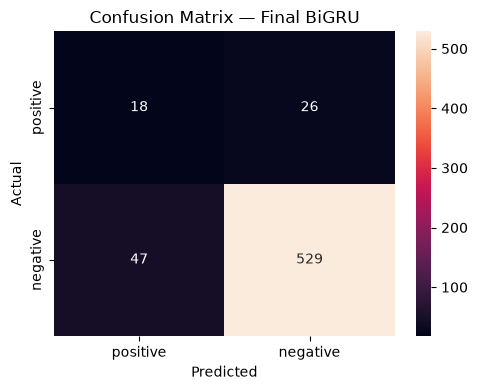

In [22]:
import seaborn as sns
if BINARY_LABELS_READY and final_model is not None:
    cm = confusion_matrix(y_test, test_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=["positive", "negative"],
        yticklabels=["positive", "negative"]
    )
    plt.title("Confusion Matrix — Final BiGRU")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()
else:
    print("Final BiGRU confusion matrix skipped because the model is unavailable.")

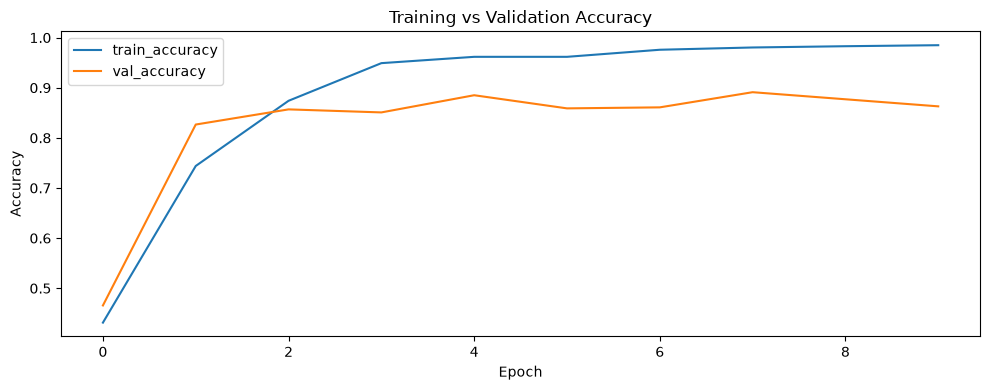

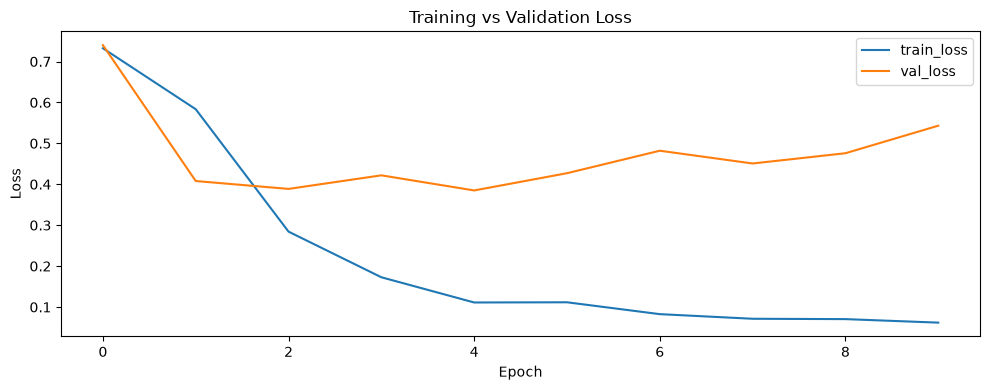

In [23]:
if BINARY_LABELS_READY and final_history is not None:
    history_df = pd.DataFrame(final_history.history)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(history_df["accuracy"], label="train_accuracy")
    ax.plot(history_df["val_accuracy"], label="val_accuracy")
    ax.set_title("Training vs Validation Accuracy")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.legend()
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(history_df["loss"], label="train_loss")
    ax.plot(history_df["val_loss"], label="val_loss")
    ax.set_title("Training vs Validation Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    plt.tight_layout()
    plt.show()

## 16. Model Comparison

Perbandingan dilakukan dari hasil yang benar-benar dihitung pada dataset ini.

Jangan menyalin angka accuracy/F1 dari notebook lain.

In [24]:
comparison_rows = [
    {"model": "TF-IDF + Logistic Regression", "accuracy": tfidf_accuracy, "macro_f1": tfidf_f1_macro}
]

if "baseline_accuracy" in globals() and not np.isnan(baseline_accuracy):
    comparison_rows.append({
        "model": "BiLSTM baseline",
        "accuracy": baseline_accuracy,
        "macro_f1": baseline_f1_macro
    })

if "test_accuracy" in globals() and not np.isnan(test_accuracy):
    comparison_rows.append({
        "model": "BiGRU candidate",
        "accuracy": test_accuracy,
        "macro_f1": final_f1_macro
    })

comparison = pd.DataFrame(comparison_rows)
display(comparison.sort_values("macro_f1", ascending=False).reset_index(drop=True))

                          model  accuracy  macro_f1
0  TF-IDF + Logistic Regression  0.933871  0.746588
1               BiLSTM baseline  0.888710  0.641032
2              BiGRU candidate  0.882258  0.632865

In [25]:
if BINARY_LABELS_READY and final_model is not None:
    print("=== Model Evaluation Summary ===")
    best_row = comparison.loc[comparison["macro_f1"].idxmax()]

    for model_name in ["BiLSTM baseline", "BiGRU candidate"]:
        rows = comparison.loc[comparison["model"] == model_name]
        if not rows.empty:
            row = rows.iloc[0]
            print(f"{model_name} accuracy : {row['accuracy']:.4f}")
            print(f"{model_name} Macro F1 : {row['macro_f1']:.4f}")

    print(
        f"Highest Macro F1 recorded in this run: "
        f"{best_row['model']} ({best_row['macro_f1']:.4f})"
    )
    print(
        "Interpretation: results apply to this test split and the dataset's "
        "AI-assisted labels."
    )
else:
    print("Model evaluation summary skipped because binary model results are not available.")

=== Model Evaluation Summary ===
TF-IDF + Logistic Regression accuracy : 0.9339
TF-IDF + Logistic Regression Macro F1 : 0.7466
BiLSTM baseline accuracy : 0.8887
BiLSTM baseline Macro F1 : 0.6410
BiGRU candidate accuracy : 0.8823
BiGRU candidate Macro F1 : 0.6329
Highest Macro F1 recorded in this run: TF-IDF + Logistic Regression (0.7466)
Interpretation: results apply to this test split and the dataset's AI-assisted labels.


## 17. Top Comments by Sentiment

Tabel ini membantu membaca contoh komentar yang masuk ke masing-masing kelas. Contoh komentar harus dipahami sebagai **sampel dari dataset**, bukan sebagai representasi seluruh masyarakat.

In [26]:
if LABELS_READY:
    display_columns = [
        c for c in [
            "comment",
            "published_at"
        ]
        if c in YT_labeled.columns
    ]

    for label in [
        "positive",
        "negative",
        "neutral"
    ]:
        subset = YT_labeled[
            YT_labeled["sentiment"] == label
        ]

        if len(subset) == 0:
            continue

        print(
            f"\n=== {label.upper()} ==="
        )

        display(
            subset[
                display_columns
            ].head(10)
        )
else:
    print(
        "Contoh berdasarkan sentiment "
        "belum tersedia karena label belum ada."
    )


=== POSITIVE ===


,comment,published_at
0,Dimane itu ya Allah semoga narik kalau mbg tid...,2026-09-21 05:06:39+00:00
4,Di sekolah ku ada mbg tapi gakpapa kok aku,2026-09-19 09:04:22+00:00
16,Mbg nya tolong stop☹️☹️,2026-09-13 04:56:22+00:00
20,Siapa yang setuju mbg di hentikan🫗,2026-09-12 01:49:40+00:00
40,Mantap MBG maju terus pecahkan rekor dunia 🌏 b...,2026-09-08 02:10:54+00:00
288,Seperti ini mau di lanjutkan.. mreka mreka yg ...,2026-06-27 18:26:44+00:00
343,SMA juga ada yang keracunan MBG 😢,2026-06-15 10:47:30+00:00
512,Aku di sekolah juga makan MBG tapi aman aja kok,2026-05-21 05:53:16+00:00
639,Untung aku makan mbg ngak keracunan🤢🤢🤢🤢🤢🤢🤢🤢🤢🤢🤢...,2026-05-14 07:01:57+00:00
644,aku tidak kayak gitu di MBG 😊,2026-05-13 22:49:36+00:00



=== NEGATIVE ===


,comment,published_at
5,MBG😢😢😢,2026-09-18 13:37:23+00:00
6,KENAPA KEPALA KELUARGA KORBAN KERACUNAN GAK AD...,2026-09-17 23:46:57+00:00
9,Politik sangatlah kejam... ternyata rakyat Ind...,2026-09-15 17:25:21+00:00
12,"Sukses pak prabowo dengan program beracun nya,...",2026-09-14 03:08:48+00:00
15,Sy sbagai org tua melarang keras kepada anak2 ...,2026-09-13 08:49:35+00:00
18,Masak sih MBG kok kalah berkualitas dari masak...,2026-09-12 13:59:20+00:00
19,Keracunan MBG yg sdh banyak mengambil korban s...,2026-09-12 10:20:55+00:00
23,KITA TUNTUT AJA BGN....\nRp. 100 T Rupiah....\...,2026-09-11 09:26:23+00:00
24,Sennang klian melihat itu kan iblis?dan berhas...,2026-09-11 02:35:34+00:00
26,Disaat pemerintah negara lain mengutamakan pen...,2026-09-10 11:31:39+00:00



=== NEUTRAL ===


,comment,published_at
1,Presiden Prabowo Ganti\n\nPresiden Pemilu 2029...,2026-09-21 02:33:45+00:00
2,Presiden Prabowo bilang sekolah Seperti pikir ...,2026-09-21 02:32:49+00:00
3,Hancurkan generasi muda dengan uang rakyat 😂😂😂...,2026-09-19 18:25:45+00:00
7,Aku jadi takutdeh😢,2026-09-17 13:04:03+00:00
8,Woi Prabowo aji** udah deh kokumsi makanan mbg,2026-09-16 07:30:08+00:00
10,Makanan yang seharusnya bergizi tetapi menjadi...,2026-09-15 08:26:41+00:00
11,Ini kenapa saya tidak pernah makan mbg.,2026-09-15 05:11:06+00:00
13,𝚃𝚄𝙽𝚃𝚄𝚃 & 𝙶𝚄𝙶𝙰𝚃 𝙿𝚁𝙰𝙱𝙾𝚆𝙾 𝙰𝚃𝙰𝚂 𝙺𝙴𝚁𝙰𝙲𝚄𝙽𝙰𝙽 𝙼𝙰𝚂𝚂𝙰𝙻 𝙰...,2026-09-13 14:38:37+00:00
14,"MBG malah bikin repot orang ,bukan nya ngebant...",2026-09-13 11:05:55+00:00
17,Astaghfirullah...\nSuruh makan yg bikin!!!!!!!!,2026-09-13 03:03:41+00:00


## 18. Results Export & Data-Driven Insight Summary

This section packages calculated outputs into reusable portfolio artifacts. The summary is generated from the actual dataset and model outputs.

In [27]:
from pathlib import Path

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

summary = {
    "dataset_rows": int(len(YT_comments)),
    "valid_labeled_rows": int(len(YT_labeled)),
    "binary_rows": int(len(YT_comments_binary)),
    "label_counts": {
        label: int(YT_labeled["sentiment"].eq(label).sum())
        for label in ["positive", "negative", "neutral"]
    },
    "empty_after_preprocessing": int(empty_after_preprocessing)
}

if len(YT_comments):
    summary["avg_comment_tokens"] = float(YT_comments["comment_length"].mean())
    summary["median_comment_tokens"] = float(YT_comments["comment_length"].median())

if len(daily_volume):
    peak_date = daily_volume.idxmax()
    summary["peak_discussion_date"] = str(peak_date)
    summary["peak_discussion_volume"] = int(daily_volume.max())

if LABELS_READY and len(sentiment_trend):
    summary["sentiment_peak_by_label"] = {
        label: {
            "date": str(sentiment_trend[label].idxmax()),
            "count": int(sentiment_trend[label].max())
        }
        for label in ["positive", "negative", "neutral"]
    }

model_metrics = [
    {
        "model": "TF-IDF + Logistic Regression",
        "accuracy": float(tfidf_accuracy),
        "macro_f1": float(tfidf_f1_macro)
    }
]

if "baseline_accuracy" in globals() and not np.isnan(baseline_accuracy):
    model_metrics.append({
        "model": "BiLSTM baseline",
        "accuracy": float(baseline_accuracy),
        "macro_f1": float(baseline_f1_macro)
    })

if "test_accuracy" in globals() and not np.isnan(test_accuracy):
    model_metrics.append({
        "model": "BiGRU candidate",
        "accuracy": float(test_accuracy),
        "macro_f1": float(final_f1_macro)
    })

model_metrics_df = pd.DataFrame(model_metrics)
model_metrics_df.to_csv(RESULTS_DIR / "model_comparison.csv", index=False)

summary["model_metrics"] = model_metrics

with open(RESULTS_DIR / "project_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

dominant_label = max(summary["label_counts"], key=summary["label_counts"].get)
dominant_pct = summary["label_counts"][dominant_label] / summary["valid_labeled_rows"] * 100

print("=== DATA-DRIVEN PROJECT SUMMARY ===")
print(f"Dataset: {summary['dataset_rows']:,} comments")
print(f"Dominant sentiment: {dominant_label} ({dominant_pct:.2f}%)")
print(
    f"Peak discussion volume: {summary.get('peak_discussion_date', 'N/A')} "
    f"({summary.get('peak_discussion_volume', 0):,} comments)"
)

print("\nModel results:")
display(model_metrics_df.sort_values("macro_f1", ascending=False).reset_index(drop=True))

print(
    "\nInterpretation note: these findings describe the collected YouTube dataset "
    "and model performance against its AI-assisted labels; they do not establish "
    "causality or represent the opinion of the entire population."
)

=== DATA-DRIVEN PROJECT SUMMARY ===
Dataset: 12,000 comments
Dominant sentiment: neutral (74.17%)
Peak discussion volume: 2026-09-21 (895 comments)

Model results:
TF-IDF + Logistic Regression | accuracy=0.9339 | macro_f1=0.7466
BiLSTM baseline             | accuracy=0.8887 | macro_f1=0.6410
BiGRU candidate             | accuracy=0.8823 | macro_f1=0.6329

Interpretation note: findings describe this YouTube dataset and model performance against AI-assisted labels; they do not establish causality or represent the opinion of the entire population.


## 19. Data-Driven Insights & Recommendations

### 19.1 Dataset & sentiment composition

Dari **12.000 komentar**, terdapat:
- **8.900 neutral (74.17%)**
- **2.880 negative (24.00%)**
- **220 positive (1.83%)**

Untuk binary modeling, neutral dikeluarkan sehingga tersisa **3.100 komentar**: **2.880 negative (92.9%)** dan **220 positive (7.1%)**.

**Interpretasi:** imbalance sangat kuat pada binary dataset. Karena itu, accuracy saja tidak cukup untuk menggambarkan performa model.

### 19.2 Discussion volume & timing

Volume diskusi tertinggi pada portfolio run terjadi pada **21 September 2026**, dengan **895 komentar**. Pada tanggal yang sama, sentiment trend mencatat **650 neutral** dan **233 negative**.

Temuan ini menunjukkan kapan percakapan paling ramai di dataset. Notebook tidak menyimpulkan penyebab lonjakan tanpa analisis eksternal.

### 19.3 Vocabulary pattern

Lima kata paling sering setelah preprocessing:
1. **mbg — 5.158**
2. **gak — 1.678**
3. **tidak — 1.218**
4. **makan — 1.111**
5. **anak — 1.064**

Pola vocabulary tersebut menunjukkan bahwa percakapan sangat berpusat pada MBG, makanan, anak, serta bahasa informal dan negasi yang umum pada komentar online.

### 19.4 Model performance

| Model | Accuracy | Macro F1 |
|---|---:|---:|
| TF-IDF + Logistic Regression | **93.39%** | **74.66%** |
| BiLSTM baseline | 88.87% | 64.10% |
| BiGRU candidate | 88.23% | 63.29% |

Pada test set, terdapat **44 positive** dan **576 negative** comments. F1 untuk kelas positive adalah **0.53** pada TF-IDF, **0.34** pada BiLSTM, dan **0.33** pada BiGRU.

**Interpretasi:** pada run ini, baseline TF-IDF + Logistic Regression memberikan Macro F1 tertinggi. Ini memperlihatkan bahwa model yang lebih kompleks tidak otomatis menghasilkan performa lebih baik pada dataset ini.

### 19.5 Data-quality observations

Data validation menemukan:
- **0 duplicate `row_id`**
- **453 duplicate exact-comment texts**
- **1 missing `comment_clean`**
- **0 invalid `published_at` values**
- **561 comments menjadi empty setelah preprocessing**

Notebook menggunakan fallback ke `comment` ketika `comment_clean` kosong, sehingga sumber teks tetap tersedia untuk preprocessing.

### Recommendations

1. **Perkuat ground truth:** buat human-annotated validation/test sample untuk memeriksa kualitas AI-assisted labels secara independen.
2. **Tangani minority class:** pertahankan class weighting dan evaluasi false positive/false negative, threshold, serta strategi sampling yang sesuai untuk data teks.
3. **Pertahankan classical baseline:** gunakan TF-IDF + Logistic Regression sebagai benchmark ketika menguji arsitektur deep learning baru.
4. **Kembangkan 3-class model:** pertahankan neutral dalam classifier berikutnya karena neutral merupakan kelas terbesar pada dataset.
5. **Eksperimen pretrained language model:** setelah kualitas label diperkuat, model bahasa pretrained Bahasa Indonesia dapat menjadi eksperimen lanjutan.

> **Interpretation boundary:** seluruh insight di atas mendeskripsikan dataset komentar YouTube dan performa model terhadap AI-assisted labels. Insight tersebut bukan estimasi opini seluruh populasi dan bukan bukti sebab-akibat.

## 20. Limitations

1. Dataset berasal dari komentar YouTube yang berhasil dikumpulkan dan tidak otomatis mewakili seluruh populasi.
2. Komentar online dapat mengandung slang, sarcasm, typo, emoji, spam, dan konteks ambigu.
3. Sentiment labels menggunakan **AI-assisted semantic labeling**, bukan human gold standard.
4. Binary subset sangat tidak seimbang: **92.9% negative vs 7.1% positive**.
5. `neutral` dipertahankan untuk analisis keseluruhan tetapi tidak digunakan dalam binary classifier.
6. BiLSTM/BiGRU berbasis sequence memiliki keterbatasan dalam memahami konteks panjang dan sarcasm.
7. Sentiment trend hanya menunjukkan perubahan pada dataset; penyebab perubahan tidak disimpulkan tanpa analisis tambahan.

## 21. Final Output

Setelah seluruh cell berhasil dijalankan, notebook menghasilkan:

- data validation & quality profile
- cleaned / preprocessed text
- comment-length analysis
- top-word frequency analysis
- sentiment distribution
- discussion-volume trend
- sentiment trend
- TF-IDF + Logistic Regression baseline
- BiLSTM baseline
- BiGRU deep-learning candidate
- classification reports
- confusion matrices
- training / validation curves
- model comparison
- representative comments
- data-driven insight summary

Semua angka yang ditampilkan pada portfolio run berasal dari eksekusi notebook terhadap `data/mbg_comments_labeled.csv`.

## 22. Reproducibility Checklist

- [x] `data/mbg_comments_labeled.csv` tersedia.
- [x] Dataset berisi 12.000 komentar berlabel.
- [x] Label hanya positive / negative / neutral.
- [x] Labeling method dijelaskan sebagai AI-assisted semantic labeling.
- [x] Train-test split menggunakan stratification dan fixed random seed.
- [x] Tokenizer hanya fit pada training set.
- [x] Test set tidak digunakan untuk tuning.
- [x] Classical TF-IDF baseline tersedia.
- [x] Accuracy dan Macro F1 dihitung dari test set.
- [x] Portfolio run memiliki execution outputs.
- [x] Portfolio run tidak memiliki error outputs.
- [x] Insight ditulis berdasarkan output aktual dataset.

## 23. Portfolio-Ready Conclusion

Project ini menunjukkan workflow end-to-end **Text Mining + NLP + Machine Learning + Deep Learning** pada 12.000 komentar YouTube terkait MBG.

Pada portfolio run, dataset didominasi neutral labels dan binary subset memiliki ketidakseimbangan kuat. Untuk evaluasi test set, **TF-IDF + Logistic Regression mencatat Macro F1 74.66%**, dibanding **64.10%** untuk BiLSTM dan **63.29%** untuk BiGRU.

Temuan ini menekankan dua hal teknis: (1) baseline sederhana perlu tetap dibandingkan dengan deep learning, dan (2) Macro F1 serta class-level metrics perlu dibaca bersama accuracy ketika distribusi kelas tidak seimbang.

Keterbatasan utama project adalah **AI-assisted labeling**, sehingga langkah pengembangan berikutnya adalah memperkuat human-annotated validation set sebelum menggunakan model sebagai sistem monitoring yang lebih serius.

> **Portfolio takeaway:** project tidak berhenti pada training model; pipeline mencakup data quality, preprocessing, exploratory text mining, sentiment trend analysis, model benchmarking, evaluation, dan data-driven interpretation.